# OODKit showcase: COCO (ID) vs COCO-O (OOD), object-detection domain

**Data layout** (expected under `COCO_ROOT` / `COCO_O_ROOT`):

```
<COCO_ROOT>/
  coco_annotations/
    instances_train2017.json
    instances_val2017.json
  coco_train/                    # image files
  coco_val/                      # image files

<COCO_O_ROOT>/
  cartoon/
    annotations/instances_val2017.json
    images/                      # image files (renamed from val2017/)
  tattoo/...
  weather/...
```

**What this notebook shows**

1. Build **chip-level** datasets from COCO ID train + val and 2-3 COCO-O OOD domains (square chips,
   `min_chip_size=25`, zero-padded at edges).
2. Train a **linear head** on COCO-train chips so logit-based detectors (Energy, ViM) have something to work with.
3. Score chips with **ViM**, **WDiscOOD**, and **Energy** - a small mix covering logit-only, residual-space,
   and discriminative-subspace methods.
4. Evaluate at **two granularities**:
   - **chip-level** (each box is one sample), and
   - **image-level** by pooling chip scores via `pool_image_scores` (`mean` / `max` / `topk_mean`).
5. Break image-level AUROC down **per OOD domain** using `metadata["group"]`.

Edit the **paths** and **training** constants in the first code cell below.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import warnings
import contextlib
import io

# --- Edit these paths for your machine, or set OODKIT_DATASETS ---------------
DATASETS_ROOT = Path(os.environ.get("OODKIT_DATASETS", "/datasets"))
COCO_ROOT = DATASETS_ROOT / "coco"
COCO_O_ROOT = DATASETS_ROOT / "coco_ood"

BACKBONE = "dinov2-small"
HEAD_EPOCHS = 3
BATCH_SIZE = 64
NUM_WORKERS = 4  # Use 0 in notebooks to avoid multiprocessing cleanup noise.
PIN_MEMORY = True
PERSISTENT_WORKERS = True

SEED = 42

# Only keep boxes whose shorter side is >= this (pixels). Tiny crowd annotations
# add a lot of noise to chip-level OOD and slow training without helping.
MIN_BOX_SIDE = 0
# Square chip side = max(longest_box_side, MIN_CHIP_SIZE).
MIN_CHIP_SIZE = 25

# Subsample to keep the first pass snappy. Set to 1.0 to use the full splits.
# Applied by selecting a random subset of **source images** (so chips from one
# image stay together), not individual chips.
TRAIN_IMAGE_FRACTION = 0.2
VAL_IMAGE_FRACTION = 0.5
OOD_IMAGE_FRACTION = 1.0

# Which COCO-O domains to evaluate on. Must exist under COCO_O_ROOT. Keep it
# small for the first run; extend once paths / GPU are happy.
OOD_DOMAINS = ["cartoon", "tattoo", "painting"]

# topk_mean pooling uses this many top-ranked chips per image.
POOL_TOPK = 3

_DL_KW = dict(
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
)


def _check_paths() -> None:
    missing = [p for p in (COCO_ROOT, COCO_O_ROOT) if not p.exists()]
    if missing:
        print("Missing paths - set OODKIT_DATASETS or update the constants at the top of this cell:", file=sys.stderr)
        for p in missing:
            print(f"  - {p}", file=sys.stderr)
        raise FileNotFoundError("Fix COCO_ROOT and COCO_O_ROOT.")


_check_paths()

In [2]:
import numpy as np
import torch

from oodkit.contrib.coco import (
    CocoCategoryTable,
    coco_chip_dataset,
    coco_ood_chip_datasets,
    discover_coco_id,
)
from oodkit.data.chip_dataset import ChipDataset
from oodkit.detectors import Energy, ViM, WDiscOOD
from oodkit.embeddings.backbones import load_backbone
from oodkit.embeddings.embedder import Embedder
from oodkit.evaluation import (
    ScoreBank,
    concatenate_embedding_results,
    evaluate,
    pool_image_scores,
)

In [3]:
def _subsample_by_image(ds: ChipDataset, fraction: float, seed: int) -> ChipDataset:
    """Return a new ``ChipDataset`` keeping a random subset of **source images**.

    Chips from the same image stay together - pooling / per-image analysis
    downstream assumes intact image groups.
    """
    if fraction >= 1.0:
        return ds
    rng = np.random.default_rng(seed)
    n_images = len(ds.image_paths)
    k = max(1, int(n_images * fraction))
    keep = np.sort(rng.choice(n_images, size=k, replace=False))
    keep_set = set(int(i) for i in keep)
    chip_mask = np.array(
        [int(i) in keep_set for i in ds.chip_to_image], dtype=bool
    )
    chip_idx = np.nonzero(chip_mask)[0].tolist()

    class _ChipSubset(torch.utils.data.Dataset):
        """Subset wrapper that preserves the attributes ``Embedder`` duck-types on.

        Critically it forwards ``classes`` so ``Embedder._infer_n_classes`` still
        sees the full 80-class COCO label space even when subsampling drops rare
        classes from the training subset.
        """

        def __init__(self, base: ChipDataset, idx: list[int]) -> None:
            self.base = base
            self.idx = idx
            raw_c2i = base.chip_to_image[idx]
            # Remap the (sparse) kept image indices to a dense 0..K-1 range so
            # pooling / per-block offsetting in concatenate_embedding_results
            # doesn't create NaN rows for absent images.
            _, self.chip_to_image = np.unique(raw_c2i, return_inverse=True)
            self.chip_to_image = self.chip_to_image.astype(np.int64)
            self.boxes = base.boxes[idx]
            self.object_ids = base.object_ids[idx]
            self.image_ids = base.image_ids[idx]
            self.groups = base.groups[idx] if base.groups is not None else None
            self.imgs = [base.imgs[i] for i in idx]
            self.targets = [lbl for _, lbl in self.imgs]
            if hasattr(base, "classes"):
                self.classes = base.classes

        def __len__(self) -> int:
            return len(self.idx)

        def __getitem__(self, i: int):
            return self.base[self.idx[i]]

    return _ChipSubset(ds, chip_idx)  # type: ignore[return-value]

In [4]:
_, processor, _ = load_backbone(BACKBONE)

coco_paths = discover_coco_id(COCO_ROOT)
category_table = CocoCategoryTable.from_coco_json(coco_paths.train_ann)
print(f"COCO classes: {category_table.num_classes}")

train_ds_full = coco_chip_dataset(
    coco_paths.train_ann,
    coco_paths.train_images,
    processor,
    group="coco_train",
    category_table=category_table,
    min_chip_size=MIN_CHIP_SIZE,
    min_box_side=MIN_BOX_SIDE,
)
val_ds_full = coco_chip_dataset(
    coco_paths.val_ann,
    coco_paths.val_images,
    processor,
    group="coco_val",
    category_table=category_table,
    min_chip_size=MIN_CHIP_SIZE,
    min_box_side=MIN_BOX_SIDE,
)
ood_ds_full = coco_ood_chip_datasets(
    COCO_O_ROOT,
    processor,
    category_table=category_table,
    only=OOD_DOMAINS,
    min_chip_size=MIN_CHIP_SIZE,
    min_box_side=MIN_BOX_SIDE,
)

train_ds = _subsample_by_image(train_ds_full, TRAIN_IMAGE_FRACTION, seed=SEED)
val_ds = _subsample_by_image(val_ds_full, VAL_IMAGE_FRACTION, seed=SEED + 1)
ood_ds = {
    name: _subsample_by_image(ds, OOD_IMAGE_FRACTION, seed=SEED + 2 + i)
    for i, (name, ds) in enumerate(ood_ds_full.items())
}

print(f"Train chips: {len(train_ds)}  |  Val chips: {len(val_ds)}")
for name, ds in ood_ds.items():
    print(f"  COCO-O[{name}] chips: {len(ds)}")

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

COCO classes: 80
Train chips: 168549  |  Val chips: 18466
  COCO-O[cartoon] chips: 8774
  COCO-O[tattoo] chips: 1489
  COCO-O[painting] chips: 4879


In [5]:
embedder = Embedder(backbone=BACKBONE)
embedder.fit(
    train_ds,
    mode="head",
    epochs=HEAD_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=1e-3,
    save=False,
    **_DL_KW,
)

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

training (head):   0%|          | 0/3 [00:00<?, ?it/s]

batches:   0%|          | 0/2634 [00:00<?, ?it/s]

batches:   0%|          | 0/2634 [00:00<?, ?it/s]

batches:   0%|          | 0/2634 [00:00<?, ?it/s]

In [6]:
with warnings.catch_warnings(), contextlib.redirect_stderr(io.StringIO()):
    warnings.simplefilter("ignore")

    train_res = embedder.extract(train_ds, batch_size=BATCH_SIZE, **_DL_KW)
    val_res = embedder.extract(val_ds, batch_size=BATCH_SIZE, **_DL_KW)
    ood_res = {
        name: embedder.extract(ds, batch_size=BATCH_SIZE, **_DL_KW)
        for name, ds in ood_ds.items()
    }
assert train_res.logits is not None and train_res.labels is not None

# Combined stream: ID (val) first, then each OOD domain. Each block flag: 0 = ID, 1 = OOD.
blocks = [val_res, *ood_res.values()]
flags = [0, *[1] * len(ood_res)]
combined, ood_labels = concatenate_embedding_results(blocks, flags)
comb_feat = combined.to_features()

id_train_feat = train_res.to_features()
y_train = train_res.labels

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(
    f"Combined: embeddings={combined.embeddings.shape}  "
    f"chips={combined.embeddings.shape[0]}  ood_labels={ood_labels.shape}"
)
print(f"Unique images in combined: {int(combined.metadata['chip_to_image'].max()) + 1}")

extracting:   0%|          | 0/2634 [00:00<?, ?it/s]

extracting:   0%|          | 0/289 [00:00<?, ?it/s]

extracting:   0%|          | 0/138 [00:00<?, ?it/s]

extracting:   0%|          | 0/24 [00:00<?, ?it/s]

extracting:   0%|          | 0/77 [00:00<?, ?it/s]

Combined: embeddings=(33608, 384)  chips=33608  ood_labels=(33608,)
Unique images in combined: 6344


In [7]:
# Fit detectors on ID train only. Keep the roster small but covering distinct families:
#   - Energy: logits-only, cheap baseline.
#   - WDiscOOD: discriminative + residual subspaces on embeddings (labels required).
#   - ViM: virtual-class score over PCA complement using head W/b.
head = embedder._head  # noqa: SLF001 - no public accessor yet
assert head is not None
W = head.weight.detach().cpu().numpy()
b = head.bias.detach().cpu().numpy()

detectors: dict = {}

energy = Energy()
energy.fit(id_train_feat)
detectors["Energy"] = energy

wd = WDiscOOD()
wd.fit(id_train_feat, y=y_train)
detectors["WDiscOOD"] = wd

vim = ViM(W, b)
vim.fit(id_train_feat)
detectors["ViM"] = vim

del id_train_feat, y_train, train_res, W, b

## Chip-level evaluation

Every box is an independent sample. Useful when you care about which *objects* are OOD rather
than which images contain OOD objects.

In [8]:
chip_scores = {name: det.score(comb_feat) for name, det in detectors.items()}

class_labels = np.asarray(combined.labels, dtype=np.int64)
class_names: list[str] = category_table.names()
n_classes = len(class_names)
group_per_chip = np.asarray(combined.metadata["group"])

chip_bank = ScoreBank(
    ood_labels=ood_labels,
    class_labels=class_labels,
    class_names=class_names,
    groups=group_per_chip,
)
for name, s in chip_scores.items():
    chip_bank.add(name, s)

chip_table = evaluate(chip_bank)
print("Chip-level metrics:")
print(chip_table)

Chip-level metrics:
Detector        AUROC     FPR@95  AUPR(OOD)   AUPR(ID)     DetErr
-----------------------------------------------------------------
Energy         0.7154     0.8113     0.6141     0.7428     0.3253
WDiscOOD       0.8206     0.6579     0.7800     0.8371     0.2518
ViM            0.9117     0.4373     0.8867     0.9149     0.1547


## Image-level evaluation via chip-score pooling

`pool_image_scores(chip_scores, chip_to_image, method=...)` collapses chips back to images.
Images with no chips become `NaN`; with the filtering above every image survives.

In [9]:
chip_to_image = np.asarray(combined.metadata["chip_to_image"], dtype=np.int64)
n_images = int(chip_to_image.max()) + 1

# Image-level ground truth: an image is OOD if ANY of its chips is OOD. (For COCO vs COCO-O
# that reduces to "the image came from a COOC-O domain" because we don't mix chips from
# different sources within a single image.)
image_ood_labels = np.zeros(n_images, dtype=np.int64)
np.maximum.at(image_ood_labels, chip_to_image, ood_labels.astype(np.int64))

for method in ("mean", "max", "topk_mean"):
    img_bank = ScoreBank(ood_labels=image_ood_labels)
    for name, s in chip_scores.items():
        pooled = pool_image_scores(
            s, chip_to_image, method=method, k=POOL_TOPK, n_images=n_images
        )
        assert not np.any(np.isnan(pooled)), "zero-chip images not expected after filtering"
        img_bank.add(name, pooled)
    print(f"\nImage-level metrics (pool={method}):")
    print(evaluate(img_bank))


Image-level metrics (pool=mean):
Detector        AUROC     FPR@95  AUPR(OOD)   AUPR(ID)     DetErr
-----------------------------------------------------------------
Energy         0.7966     0.8150     0.8653     0.6655     0.2586
WDiscOOD       0.8845     0.4750     0.9015     0.8392     0.1811
ViM            0.9302     0.2460     0.9334     0.8901     0.1247

Image-level metrics (pool=max):
Detector        AUROC     FPR@95  AUPR(OOD)   AUPR(ID)     DetErr
-----------------------------------------------------------------
Energy         0.5753     0.8712     0.6243     0.5000     0.4121
WDiscOOD       0.8063     0.6733     0.8441     0.7323     0.2611
ViM            0.8786     0.5368     0.8896     0.8103     0.1799

Image-level metrics (pool=topk_mean):
Detector        AUROC     FPR@95  AUPR(OOD)   AUPR(ID)     DetErr
-----------------------------------------------------------------
Energy         0.6424     0.8449     0.6811     0.5542     0.3760
WDiscOOD       0.8506     0.5828    

## Per-OOD-domain breakdown

Slice the combined stream by `metadata["group"]` so we can tell which OOD domain (cartoon, tattoo,
painting, ...) each detector struggles with. We score at **image level** with `topk_mean` pooling
since it empirically tracks scene-level OOD better than plain mean.

In [10]:
# Build per-image group: all chips from the same image share the same group, so
# an arbitrary "last write wins" indexed assignment recovers it safely.
image_group = np.empty(n_images, dtype=object)
image_group[chip_to_image] = group_per_chip

pooled_per_detector = {
    name: pool_image_scores(
        s, chip_to_image, method="topk_mean", k=POOL_TOPK, n_images=n_images
    )
    for name, s in chip_scores.items()
}

print("Image-level AUROC per OOD domain (pool=topk_mean):\n")
for domain in OOD_DOMAINS:
    if not np.any(image_group == domain):
        print(f"  [skip] {domain} has no images in the combined stream")
        continue
    domain_mask = (image_group == domain) | (image_group == "coco_val")
    sub_bank = ScoreBank(ood_labels=image_ood_labels[domain_mask])
    for name, pooled in pooled_per_detector.items():
        sub_bank.add(name, pooled[domain_mask])
    print(f"  [{domain}]")
    print(evaluate(sub_bank))
    print()

Image-level AUROC per OOD domain (pool=topk_mean):

  [cartoon]
Detector        AUROC     FPR@95  AUPR(OOD)   AUPR(ID)     DetErr
-----------------------------------------------------------------
Energy         0.6688     0.7690     0.5374     0.7387     0.3557
WDiscOOD       0.9016     0.3720     0.8472     0.9269     0.1638
ViM            0.9516     0.2100     0.9112     0.9606     0.0974

  [tattoo]
Detector        AUROC     FPR@95  AUPR(OOD)   AUPR(ID)     DetErr
-----------------------------------------------------------------
Energy         0.6103     0.8748     0.3058     0.8175     0.3784
WDiscOOD       0.8746     0.4996     0.6945     0.9449     0.1928
ViM            0.9060     0.5295     0.7521     0.9530     0.1446

  [painting]
Detector        AUROC     FPR@95  AUPR(OOD)   AUPR(ID)     DetErr
-----------------------------------------------------------------
Energy         0.6180     0.9116     0.3697     0.7936     0.4070
WDiscOOD       0.7208     0.7855     0.4741     0.86

## Deeper chip-level analysis: per (class x group)

Above we looked at detectors aggregated over all chips and then sliced by OOD domain.
COCO has 80 classes though, and whether a detector separates "cartoon cats from real cats"
is a very different question from "cartoon dining tables from real dining tables". Below we
compute **chip-level AUROC per (class, OOD group)** for a handful of frequent classes, using
ID chips from `coco_val` paired with OOD chips from each COCO-O domain.

A cell with `NaN` means that (class, group) pair didn't have chips on both sides of the
comparison in this run - usually because the class is rare in one of the subsampled splits.

In [11]:
import pandas as pd
from oodkit.evaluation.metrics import auroc

# Pick a handful of frequent classes in the ID val split so the table is populated.
id_mask = group_per_chip == "coco_val"
id_class_counts = np.bincount(class_labels[id_mask], minlength=n_classes)
TOP_CLASSES = 6
top_class_idx = np.argsort(-id_class_counts)[:TOP_CLASSES]
focus_classes = [(int(c), class_names[int(c)]) for c in top_class_idx if id_class_counts[int(c)] > 0]
print("Focus classes (by coco_val chip count):")
for c, name in focus_classes:
    print(f"  {name:<20s} ({id_class_counts[c]} ID chips)")


def class_group_auroc(
    scores: np.ndarray,
    *,
    class_labels: np.ndarray = class_labels,
    groups: np.ndarray = group_per_chip,
    ood_labels: np.ndarray = ood_labels,
    classes: list[tuple[int, str]],
    ood_groups: list[str],
    id_group: str = "coco_val",
    min_per_side: int = 5,
) -> pd.DataFrame:
    """AUROC per (class, OOD group) for a single detector's chip scores.

    Each (class, ood_group) cell compares ID chips from ``id_group`` with OOD chips from
    ``ood_group`` restricted to chips with the matching class label. Cells with fewer
    than ``min_per_side`` chips on either side become ``NaN``.
    """
    rows = []
    for cls_int, cls_name in classes:
        cls_mask = class_labels == cls_int
        id_sub = cls_mask & (groups == id_group)
        row = {}
        for g in ood_groups:
            ood_sub = cls_mask & (groups == g)
            if id_sub.sum() < min_per_side or ood_sub.sum() < min_per_side:
                row[g] = np.nan
                continue
            idx = np.nonzero(id_sub | ood_sub)[0]
            row[g] = auroc(scores[idx], ood_labels[idx])
        rows.append(row)
    return pd.DataFrame(rows, index=[name for _, name in classes])


class_group_tables = {
    name: class_group_auroc(
        s,
        classes=focus_classes,
        ood_groups=OOD_DOMAINS,
    )
    for name, s in chip_scores.items()
}

for name, df in class_group_tables.items():
    print(f"\nChip-level AUROC per (class, OOD group) - {name}")
    print(df.round(3).to_string())

Focus classes (by coco_val chip count):
  person               (5380 ID chips)
  car                  (981 ID chips)
  chair                (854 ID chips)
  bottle               (592 ID chips)
  book                 (587 ID chips)
  cup                  (464 ID chips)

Chip-level AUROC per (class, OOD group) - Energy
        cartoon  tattoo  painting
person    0.754   0.802     0.742
car       0.741   0.636     0.810
chair     0.536   0.647     0.658
bottle    0.638   0.762     0.722
book      0.785   0.860     0.856
cup       0.679   0.786     0.814

Chip-level AUROC per (class, OOD group) - WDiscOOD
        cartoon  tattoo  painting
person    0.910   0.911     0.655
car       0.953   0.961     0.739
chair     0.903   0.877     0.733
bottle    0.888   0.915     0.734
book      0.890   0.977     0.873
cup       0.849   0.905     0.690

Chip-level AUROC per (class, OOD group) - ViM
        cartoon  tattoo  painting
person    0.985   0.973     0.880
car       0.967   0.953     0.885
chai

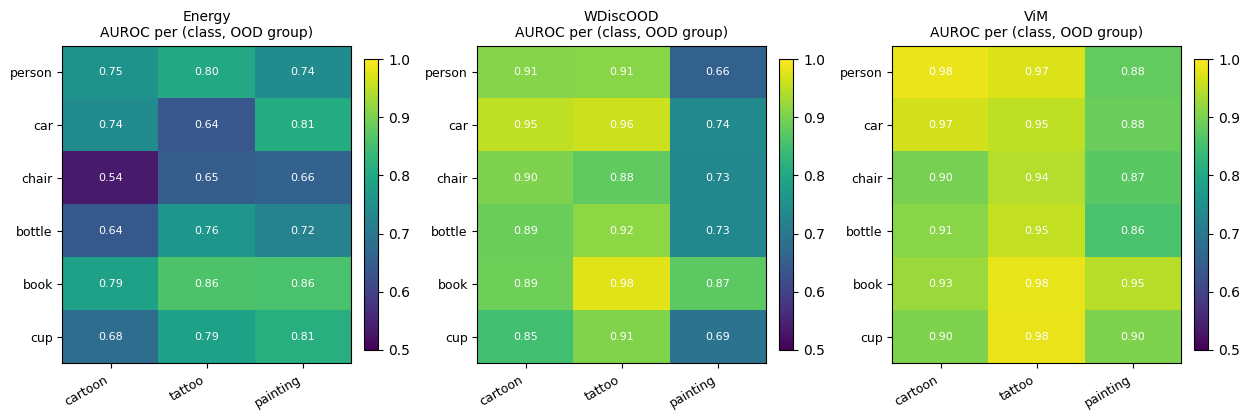

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1, len(class_group_tables),
    figsize=(4.2 * len(class_group_tables), 1 + 0.55 * len(focus_classes)),
    squeeze=False,
)
for ax, (name, df) in zip(axes.ravel(), class_group_tables.items()):
    im = ax.imshow(df.values, vmin=0.5, vmax=1.0, cmap="viridis", aspect="auto")
    ax.set_title(f"{name}\nAUROC per (class, OOD group)", fontsize=10)
    ax.set_xticks(range(df.shape[1]))
    ax.set_xticklabels(df.columns, rotation=30, ha="right", fontsize=9)
    ax.set_yticks(range(df.shape[0]))
    ax.set_yticklabels(df.index, fontsize=9)
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            v = df.values[i, j]
            txt = "-" if np.isnan(v) else f"{v:.2f}"
            ax.text(j, i, txt, ha="center", va="center", fontsize=8, color="white")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

## Score-distribution grid: class x OOD group

The AUROC heatmap tells you *how separable* each (class, group) slice is; the KDE grid below
tells you *why*. Each row fixes a class and shares an x-axis so you can see the ID
distribution (solid) vs each OOD group's distribution (dashed) shift relative to each other.
One figure per detector - score scales differ across detectors, so mixing them in one
figure hides more than it shows.

Cells with fewer than `min_per_side` chips on either side are skipped with a "-" marker
(same convention as the AUROC heatmap).

Pass `standardize=True` to z-score the scores against the detector's own ID pool (all
classes of `coco_val`). That re-centers every detector's ID distribution at 0 with unit
variance so x-axes carry the same "ID std" meaning across detectors - useful when eyeballing
multiple figures side by side.

In [13]:
from scipy.stats import gaussian_kde


def score_kde_grid(
    detector: str,
    *,
    classes: list[str] | None = None,
    n_top_classes: int = 6,
    groups: list[str] | None = None,
    standardize: bool = False,
    bandwidth: str | float = "scott",
    n_points: int = 256,
    min_per_side: int = 5,
    figsize_per_cell: tuple[float, float] = (2.8, 2.1),
):
    """KDE grid of ID vs per-OOD-group scores, per class, for one detector.

    Rows are classes; columns are OOD groups. Each cell overlays the ID score KDE with
    that group's OOD score KDE, both restricted to chips with the row's class label.
    X-axis is shared per row so shifts between ID and OOD are directly comparable.

    Args:
        detector: Key into ``chip_scores``.
        classes: Class names to show as rows. Defaults to the top ``n_top_classes``
            by ID chip count in ``coco_val``.
        n_top_classes: Only used when ``classes`` is ``None``.
        groups: OOD groups to show as columns. Defaults to ``OOD_DOMAINS``.
        standardize: If ``True``, z-score all scores using the detector's ID-pool
            (``group == "coco_val"``) mean and std across all classes before
            plotting. Makes x-axes comparable across detectors - the ID
            distribution is centered at 0 with unit variance, and OOD shifts read
            as "how many ID std away". Purely visual; ranking and AUROC are
            unchanged. A faint vertical line at ``x=0`` is drawn as the ID
            reference when enabled.
        bandwidth: Forwarded to :class:`scipy.stats.gaussian_kde`.
        n_points: Number of x-axis points per KDE evaluation.
        min_per_side: A cell needs at least this many chips on both sides; otherwise
            it's left empty with a "-" annotation.
        figsize_per_cell: Per-cell size hint.

    Returns:
        The matplotlib ``Figure``.
    """
    if detector not in chip_scores:
        raise KeyError(f"detector {detector!r} not in chip_scores {list(chip_scores)}")

    if classes is None:
        id_mask = group_per_chip == "coco_val"
        id_counts = np.bincount(class_labels[id_mask], minlength=n_classes)
        picks = np.argsort(-id_counts)[:n_top_classes]
        classes = [class_names[int(c)] for c in picks if id_counts[int(c)] > 0]
    if groups is None:
        groups = list(OOD_DOMAINS)

    scores = chip_scores[detector]
    if standardize:
        id_all = scores[group_per_chip == "coco_val"]
        if id_all.size < 2:
            raise ValueError(
                "standardize=True requires at least 2 ID chips in coco_val "
                "to estimate mean/std."
            )
        id_mean = float(np.mean(id_all))
        id_std = float(np.std(id_all))
        if id_std <= 0:
            raise ValueError(
                "standardize=True: ID score std is non-positive; cannot z-score."
            )
        scores = (scores - id_mean) / id_std

    fig, axes = plt.subplots(
        len(classes), len(groups),
        figsize=(figsize_per_cell[0] * len(groups), figsize_per_cell[1] * len(classes)),
        squeeze=False,
        sharex="row",
    )

    for r, cls_name in enumerate(classes):
        cls_int = class_names.index(cls_name)
        cls_mask = class_labels == cls_int
        id_scores = scores[cls_mask & (group_per_chip == "coco_val")]

        row_concat: list[np.ndarray] = []
        if id_scores.size >= min_per_side:
            row_concat.append(id_scores)
        for g in groups:
            gs = scores[cls_mask & (group_per_chip == g)]
            if gs.size >= min_per_side:
                row_concat.append(gs)

        if row_concat:
            row_all = np.concatenate(row_concat)
            lo, hi = float(np.min(row_all)), float(np.max(row_all))
            pad = 0.05 * (hi - lo) if hi > lo else 1.0
            xs = np.linspace(lo - pad, hi + pad, n_points)
        else:
            xs = np.linspace(0.0, 1.0, n_points)

        for c, g in enumerate(groups):
            ax = axes[r, c]
            ood_scores = scores[cls_mask & (group_per_chip == g)]

            id_ok = id_scores.size >= min_per_side
            ood_ok = ood_scores.size >= min_per_side
            if not id_ok and not ood_ok:
                ax.text(0.5, 0.5, "-", transform=ax.transAxes,
                        ha="center", va="center", fontsize=14, color="0.6")
                ax.set_xticks([])
                ax.set_yticks([])
            else:
                if id_ok:
                    kde_id = gaussian_kde(id_scores, bw_method=bandwidth)
                    ax.plot(xs, kde_id(xs), color="steelblue", linewidth=1.6, label="ID")
                    ax.fill_between(xs, kde_id(xs), color="steelblue", alpha=0.20)
                if ood_ok:
                    kde_ood = gaussian_kde(ood_scores, bw_method=bandwidth)
                    ax.plot(xs, kde_ood(xs), color="tomato", linewidth=1.6,
                            linestyle="--", label=f"OOD:{g}")
                    ax.fill_between(xs, kde_ood(xs), color="tomato", alpha=0.20)
                if standardize:
                    ax.axvline(0.0, color="0.5", linestyle=":", linewidth=0.8)

                ax.text(
                    0.98, 0.92,
                    f"n_id={id_scores.size}\nn_ood={ood_scores.size}",
                    transform=ax.transAxes, ha="right", va="top",
                    fontsize=7, color="0.3",
                )
                if r == 0 and id_ok and ood_ok:
                    ax.legend(fontsize=7, loc="upper left")

            if r == 0:
                ax.set_title(g, fontsize=9)
            if c == 0:
                ax.set_ylabel(cls_name, fontsize=9)
            ax.tick_params(axis="both", labelsize=7)

    x_units = "ID z-score" if standardize else "raw score"
    fig.suptitle(
        f"{detector}: score KDE by (class x OOD group), ID = coco_val  [{x_units}]",
        fontsize=11,
    )
    fig.tight_layout()
    return fig

### Energy

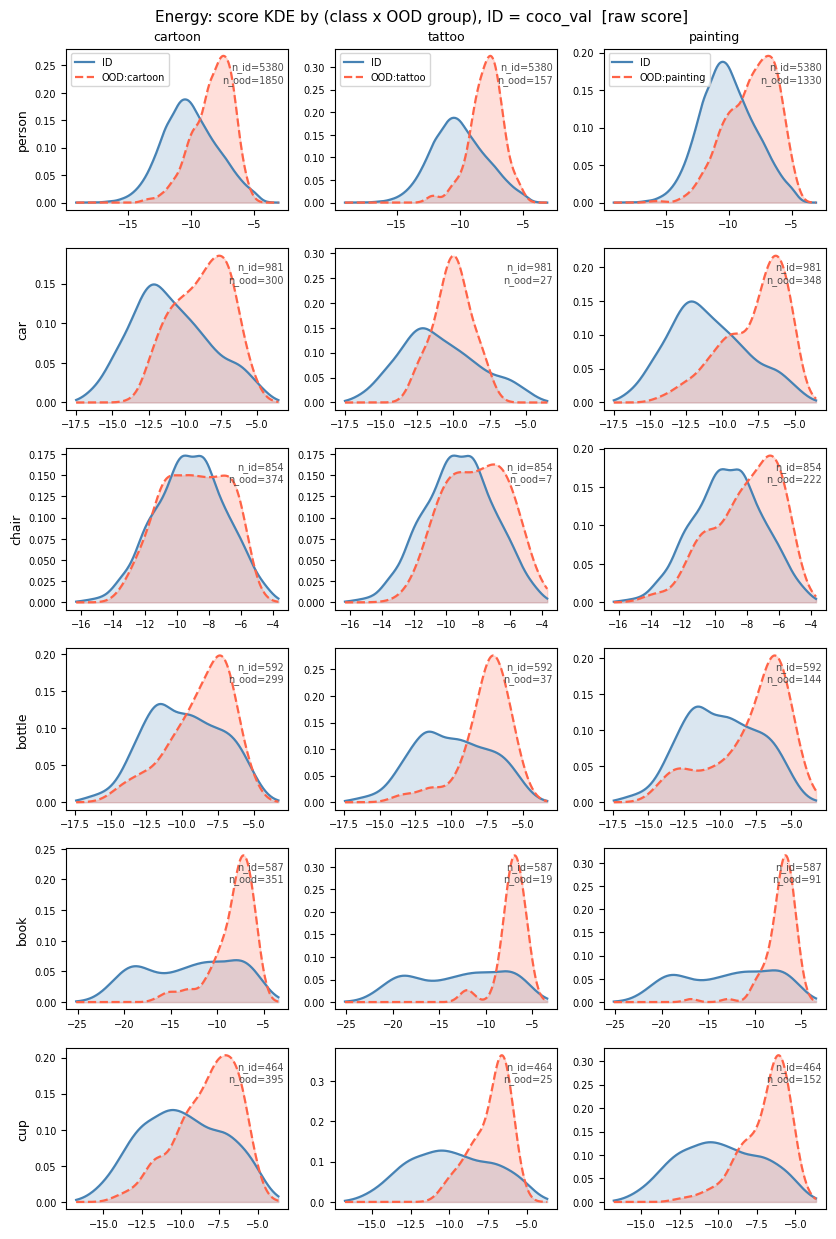

In [14]:
score_kde_grid("Energy")
plt.show()

### WDiscOOD

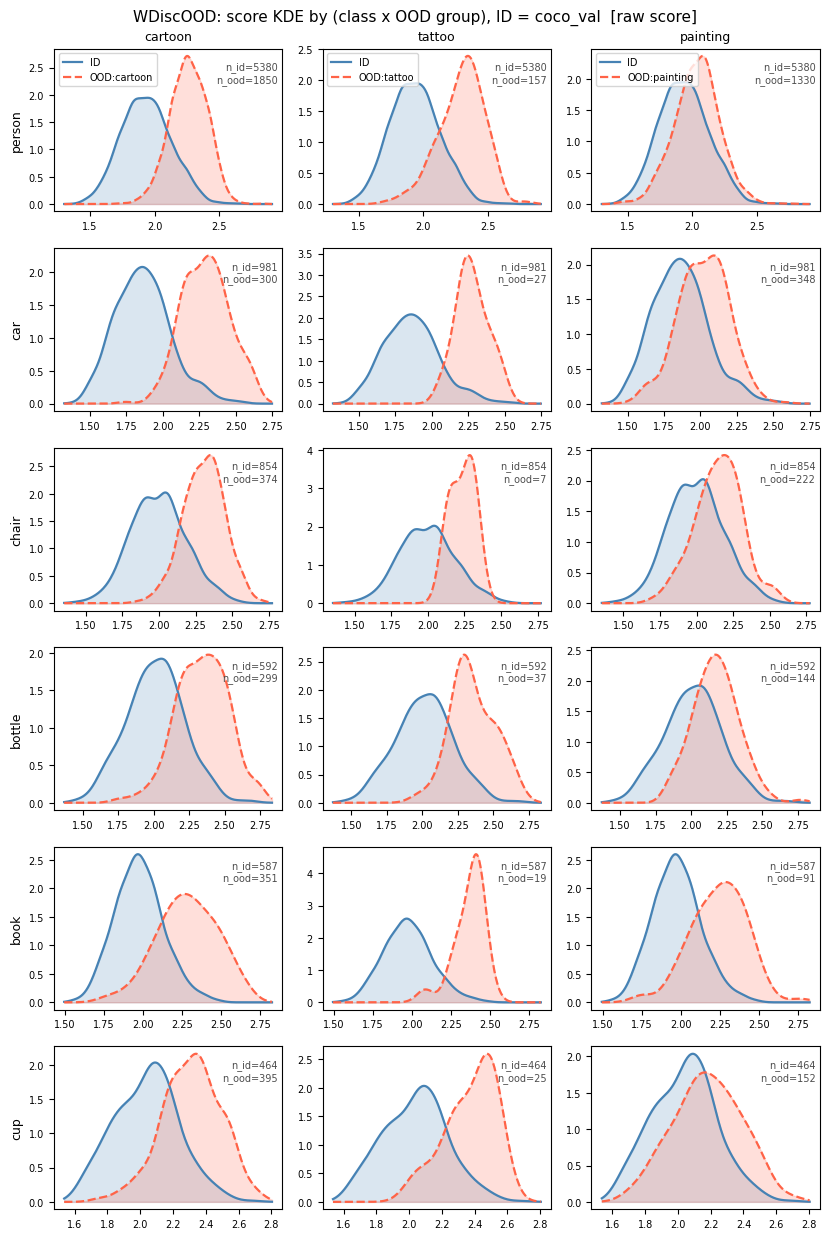

In [15]:
score_kde_grid("WDiscOOD")
plt.show()

### ViM

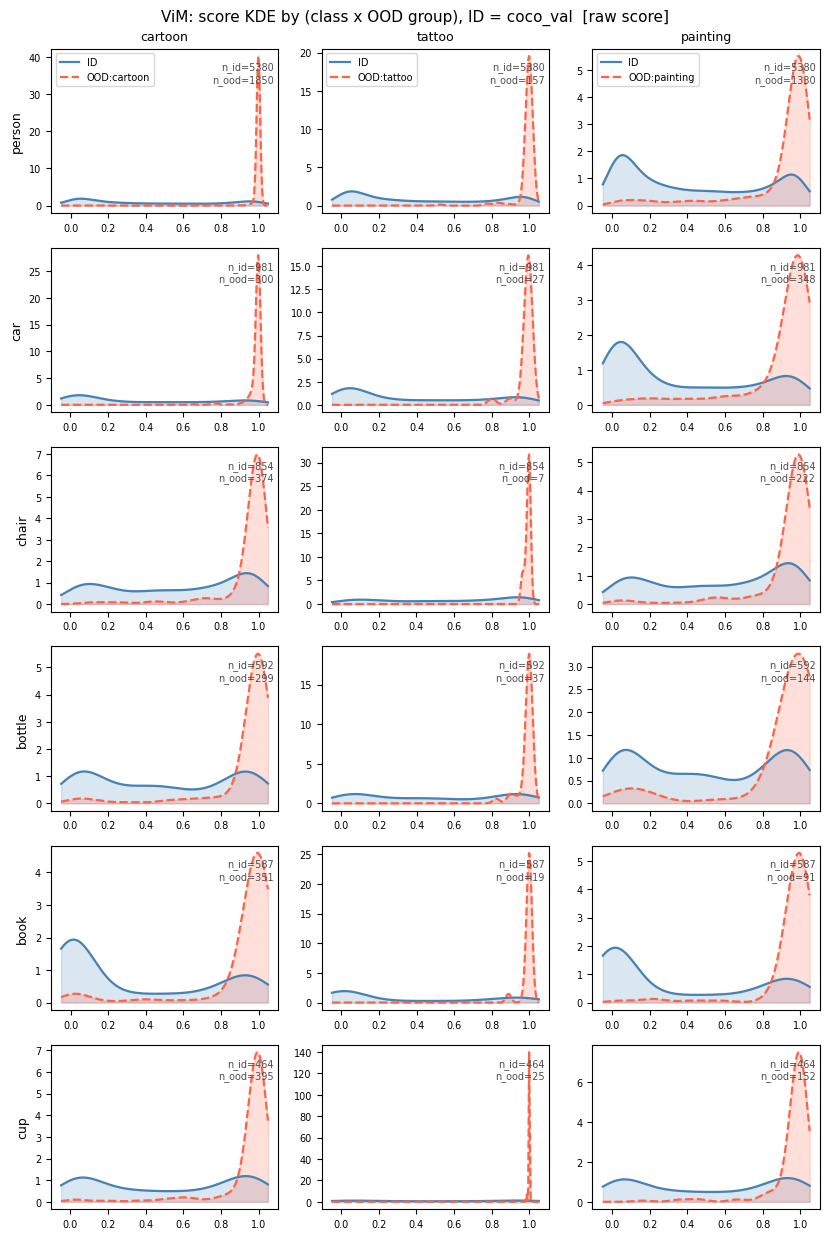

In [16]:
score_kde_grid("ViM")
plt.show()

### Cross-detector comparison (standardized)

Same three detectors with `standardize=True`. Each figure's x-axis is now in units of
"ID standard deviations", so OOD shifts can be compared across detectors. A dotted line at
`x=0` marks the ID-pool mean.

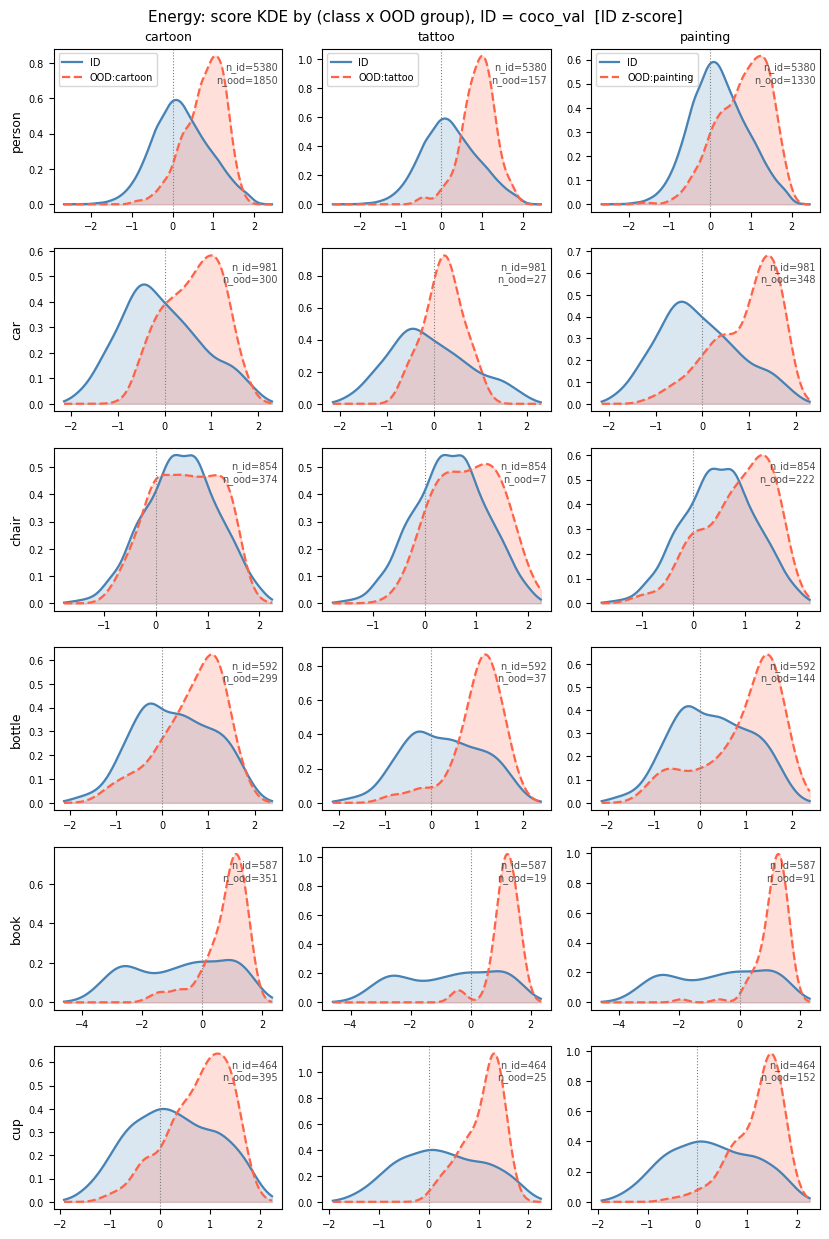

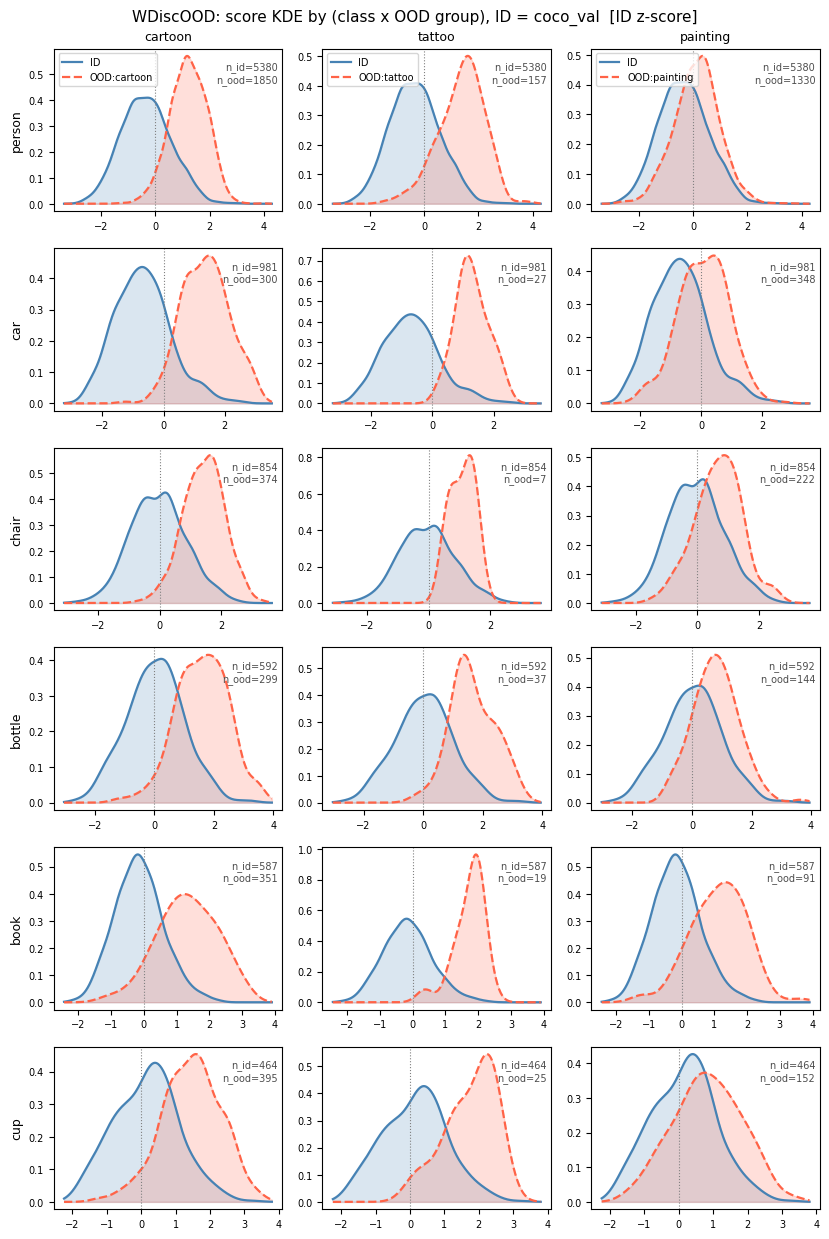

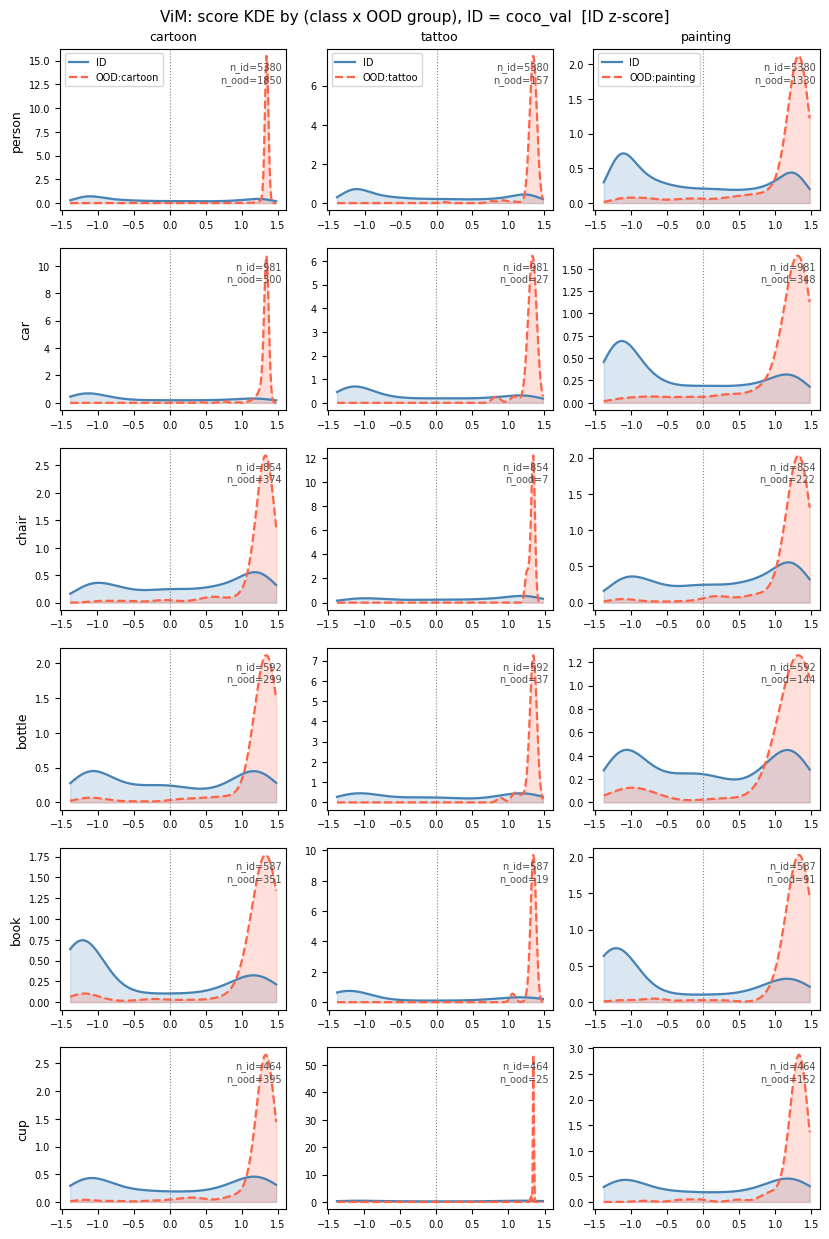

In [17]:
for name in ("Energy", "WDiscOOD", "ViM"):
    score_kde_grid(name, standardize=True)
    plt.show()

## Visual inspection: top / bottom chips by detector score

Numerical AUROC only goes so far - eyeballing the chips with the highest (or lowest) OOD
scores often reveals whether a detector is picking up on what we expect. We use the
library helper `oodkit.evaluation.plots.rank_grid` with the enriched `chip_bank` (which
already carries `class_labels`, `class_names`, `groups`, and `ood_labels`), plus a small
chip-cropping loader so `rank_grid` can render thumbnails on the fly.

The library takes care of filtering and ranking; we just pass `class_name`, `group`,
`truth` (``"id"`` / ``"ood"``), and a `rank_range` (``(start, end)``).

In [18]:
from PIL import Image

from oodkit.data.chips import crop_chip
from oodkit.evaluation.plots import rank_grid

combined_image_paths: list[str] = list(combined.metadata["image_paths"])
combined_boxes = np.asarray(combined.metadata["boxes"], dtype=np.float64)


class ChipImageLoader:
    """Sample-aligned on-demand chip cropper for ``rank_grid(images=...)``."""

    def __init__(self, paths, boxes, *, min_chip_size: int = MIN_CHIP_SIZE):
        self._paths = paths
        self._boxes = boxes
        self._min_chip_size = min_chip_size

    def __getitem__(self, idx: int):
        image_np = np.asarray(Image.open(self._paths[idx]).convert("RGB"))
        return crop_chip(image_np, self._boxes[idx], min_chip_size=self._min_chip_size)


chip_images = ChipImageLoader(combined_image_paths, combined_boxes)

### Energy: top cartoon "cat" chips

Energy is a pure logit-based baseline. Filtering to (cartoon, cat) lets us see whether the
*most-OOD* cartoon cats look visually cartoon-y; a good detector should surface stylized
drawings rather than photos that happened to be mislabeled.

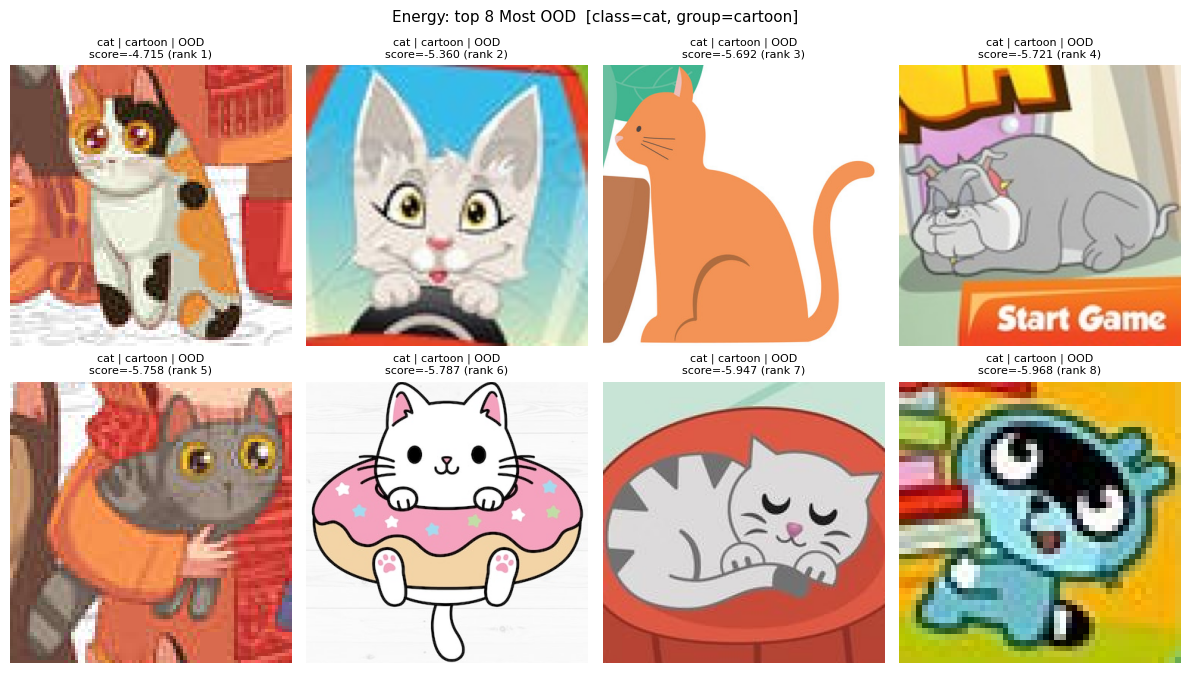

In [19]:
rank_grid(
    chip_bank, "Energy", images=chip_images,
    rank_range=(0, 8), direction="ood",
    class_name="cat", group="cartoon",
)
plt.show()

### WDiscOOD: top-scoring chips overall

Leaving class / group unfiltered shows what WDiscOOD considers the single most-OOD chips in
the entire combined stream - handy for catching labeling noise or surprising ID outliers.

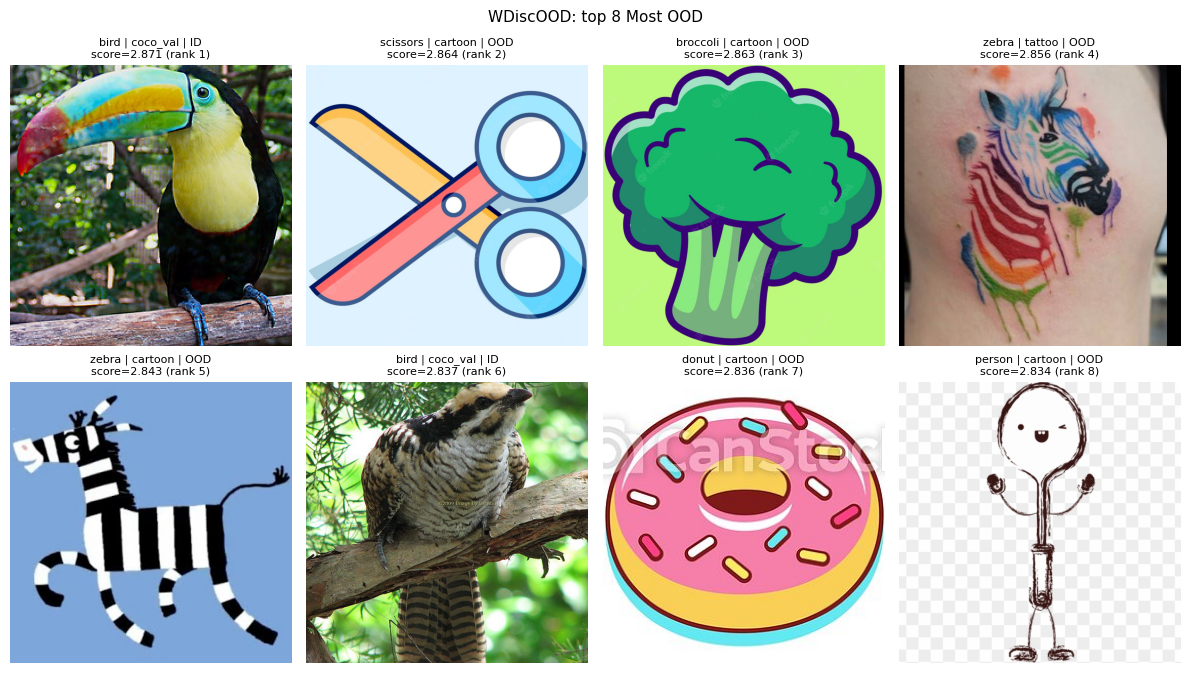

In [20]:
rank_grid(
    chip_bank, "WDiscOOD", images=chip_images,
    rank_range=(0, 8), direction="ood"
)
plt.show()

### ViM: painting "person" - most ID-like chips

Flipping direction to `"id"` surfaces OOD chips the detector **failed** to flag
(low scores). For ViM on painting-person, these are OOD chips the model thinks look most
like a normal COCO person - often the hardest failure cases to debug.

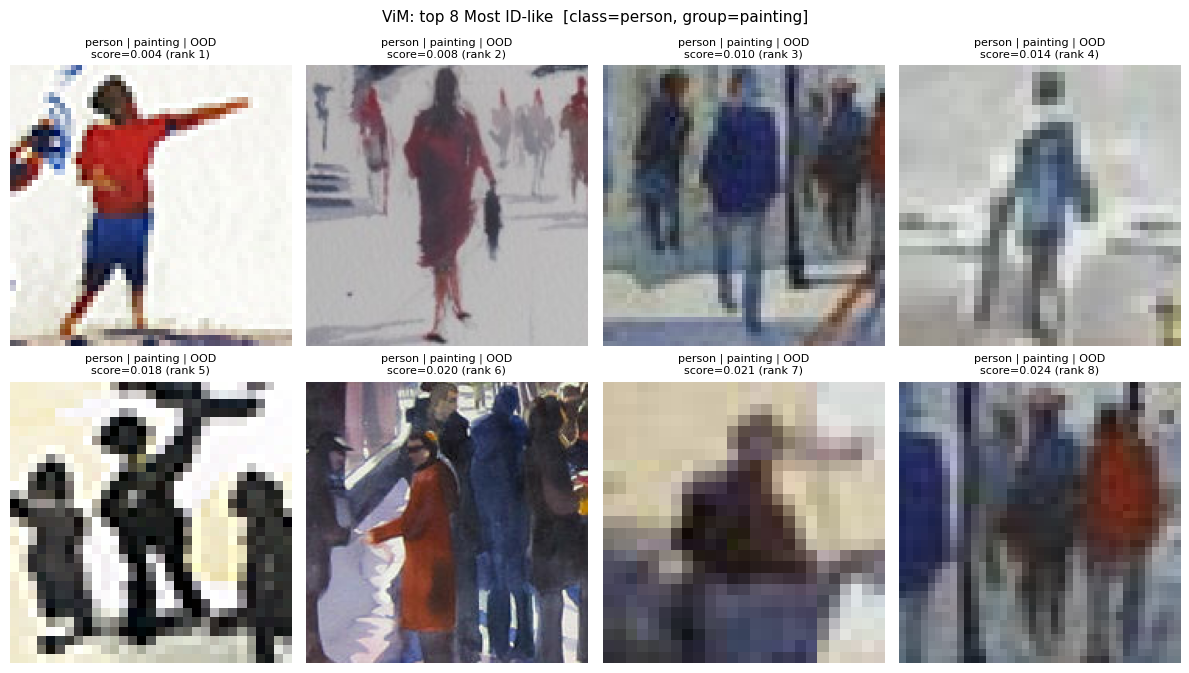

In [21]:
rank_grid(
    chip_bank, "ViM", images=chip_images,
    rank_range=(0, 8), direction="id",
    class_name="person", group="painting", 
)
plt.show()

## Notes and caveats

- **Ground-truth boxes only.** This demo assumes annotated boxes; a real OOD pipeline around a
  detector would use its *predicted* boxes (plus confidence) and likely confidence-weight the pool.
- **Chip != detection.** Chip-level AUROC reports how separable individual objects are, not end-to-end
  detector performance.
- **Pooling choice matters.** `mean` tends to under-react to rare strong evidence; `max` is brittle to
  a single high-scoring chip; `topk_mean` is a cheap compromise. Future work will explore geometry- / context-aware pooling.
- **Domain coverage.** `OOD_DOMAINS` above lists the COCO-O splits evaluated. Extend once the
  first pass runs cleanly end-to-end.